# MedClassifyAI - Medical Text Classification with DistilBERT

This notebook contains:
1. Dataset loading
2. Data exploration
3. Baseline model
4. DistilBERT fine-tuning
5. Evaluation
6. Explainability
7. Deployment

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

In [2]:
dataset = load_dataset("armanc/pubmed-rct20k")
dataset

README.md:   0%|          | 0.00/646 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/40.7M [00:00<?, ?B/s]

dev.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/176642 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/29672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29578 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})

In [3]:
print("Training samples:", len(dataset["train"]))
print("Validation samples:", len(dataset["validation"]))
print("Test samples:", len(dataset["test"]))

Training samples: 176642
Validation samples: 29672
Test samples: 29578


In [5]:
dataset["train"][0]

{'abstract_id': '24293578',
 'label': 'objective',
 'text': 'To investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .',
 'sentence_id': 0}

In [8]:
label_names = [
    "BACKGROUND",
    "CONCLUSIONS",
    "METHODS",
    "OBJECTIVE",
    "RESULTS"
]

label_names

['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS']

In [9]:
for i, label in enumerate(label_names):
    print(f"{i} -> {label}")

0 -> BACKGROUND
1 -> CONCLUSIONS
2 -> METHODS
3 -> OBJECTIVE
4 -> RESULTS


In [12]:
for i in range(5):
    sample = dataset["train"][i]
    print("Text:", sample["text"])
    print("Label:", sample["label"])
    print("-" * 80)

Text: To investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .
Label: objective
--------------------------------------------------------------------------------
Text: A total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .
Label: methods
--------------------------------------------------------------------------------
Text: Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .
Label: methods
--------------------------------------------------------------------------------
Text: Pain was assessed using the visual analog pain scale ( @-@ mm ) .
Label: methods
-------------------------------------------------------------------------

In [13]:
train_df = pd.DataFrame(dataset["train"])
train_df["label_name"] = train_df["label"]
train_df.head()

,abstract_id,label,text,sentence_id,label_name
0,24293578,objective,To investigate the efficacy of @ weeks of dail...,0,objective
1,24293578,methods,A total of @ patients with primary knee OA wer...,1,methods
2,24293578,methods,Outcome measures included pain reduction and i...,2,methods
3,24293578,methods,Pain was assessed using the visual analog pain...,3,methods
4,24293578,methods,Secondary outcome measures included the Wester...,4,methods


In [15]:
train_df["label_name"].value_counts()

label_name
methods        59281
results        57953
conclusions    27168
background     18402
objective      13838
Name: count, dtype: int64

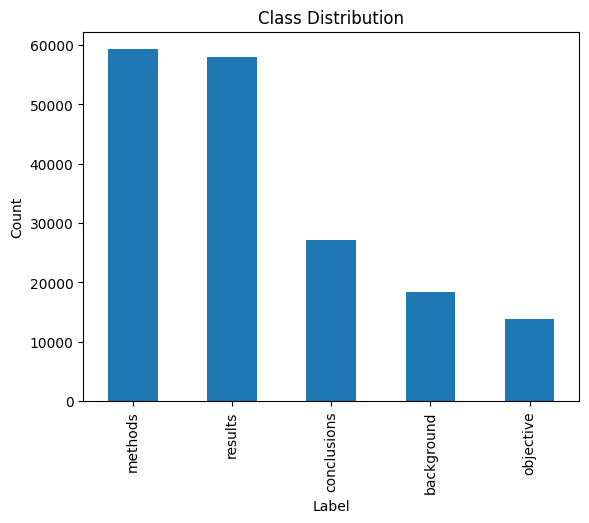

In [16]:
import matplotlib.pyplot as plt

train_df["label_name"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [17]:
train_df["text_length"] = train_df["text"].apply(len)
train_df["text_length"].describe()

count    176642.000000
mean        151.302946
std          76.454713
min           1.000000
25%          98.000000
50%         138.000000
75%         190.000000
max        1386.000000
Name: text_length, dtype: float64

# Phase 3: TF-IDF + Logistic Regression Baseline

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [19]:
# Convert dataset splits to pandas DataFrames
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

# Features and labels
X_train = train_df["text"]
y_train = train_df["label"]

X_val = val_df["text"]
y_val = val_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 176642
Validation samples: 29672
Test samples: 29578


In [20]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

TF-IDF matrix shape: (176642, 50000)


In [21]:
baseline_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

c:\Users\SUHAIL\Desktop\medclassify-ai\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
val_preds = baseline_model.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, val_preds)
val_f1 = f1_score(y_val, val_preds, average="weighted")

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation F1 Score: {val_f1:.4f}")

Validation Accuracy: 0.7790
Validation F1 Score: 0.7746


In [23]:
test_preds = baseline_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds, average="weighted")

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.7755
Test F1 Score: 0.7710


In [24]:
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

  background       0.57      0.54      0.56      3077
 conclusions       0.69      0.68      0.69      4571
     methods       0.83      0.90      0.86      9884
   objective       0.66      0.48      0.55      2333
     results       0.84      0.84      0.84      9713

    accuracy                           0.78     29578
   macro avg       0.72      0.69      0.70     29578
weighted avg       0.77      0.78      0.77     29578



In [25]:
sample_texts = [
    "Patients were randomly assigned to two treatment groups.",
    "The treatment significantly improved survival rates.",
    "These findings suggest the intervention is effective.",
    "Cardiovascular disease is a leading cause of death.",
    "The aim of this study was to evaluate safety."
]

sample_vectors = tfidf.transform(sample_texts)
sample_predictions = baseline_model.predict(sample_vectors)

for text, pred in zip(sample_texts, sample_predictions):
    print("Text:", text)
    print("Prediction:", pred)
    print("-" * 80)

Text: Patients were randomly assigned to two treatment groups.
Prediction: methods
--------------------------------------------------------------------------------
Text: The treatment significantly improved survival rates.
Prediction: results
--------------------------------------------------------------------------------
Text: These findings suggest the intervention is effective.
Prediction: conclusions
--------------------------------------------------------------------------------
Text: Cardiovascular disease is a leading cause of death.
Prediction: background
--------------------------------------------------------------------------------
Text: The aim of this study was to evaluate safety.
Prediction: objective
--------------------------------------------------------------------------------


In [27]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(baseline_model, "../models/logistic_regression_baseline.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Baseline model saved successfully!")

Baseline model saved successfully!
